In [2]:
# ============================================================
# CELL 1: SETUP
# ============================================================

!pip install rasterio --quiet

import torch
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'✅ GPU Ready: {gpu_name} ({gpu_mem:.1f} GB)')
else:
    print('⚠️ NO GPU! Go to Runtime → Change runtime type → T4 GPU')

print('✅ Cell 1 complete.')

✅ GPU Ready: Tesla T4 (15.6 GB)
✅ Cell 1 complete.


In [3]:
# ============================================================
# CELL 2: CONFIGURATION
# ============================================================
import os

# ──── LIST ALL UPLOADED FILES ────
print('📁 Files found in /content/:\n')
for f in sorted(os.listdir('/content/')):
    fpath = os.path.join('/content/', f)
    if os.path.isfile(fpath):
        size_mb = os.path.getsize(fpath) / 1e6
        print(f'  📄 {f:45s} ({size_mb:.1f} MB)')

# ──── SET YOUR FILE PATHS (edit filenames if different) ────
IMG_T1_PATH      = '/content/Aligned_2016_FINAL.tif'
IMG_T2_PATH      = '/content/Aligned_2025_MATCHED.tif'
CHANGE_MASK_PATH = '/content/change_mask.tif'
TRAINING_CSV     = '/content/training_data.csv'
OUTPUT_DIR       = '/content/outputs'

# Optional: BiFormer backbone (set None if not available)
BIFORMER_FILE    = None  # e.g. '/content/try_Bi_former_Unet.py'
PRETRAINED_PATH  = None  # e.g. '/content/biformer_pretrained.pth'

# ──── TRAINING SETTINGS ────
PATCH_SIZE  = 256    # Must be divisible by 16
STRIDE      = 128    # Overlap between patches
BATCH_SIZE  = 8      # Reduce to 4 if CUDA OOM
EPOCHS      = 100
LR          = 1e-4
NUM_BANDS   = 3      # 3=RGB, 4=RGB+NIR
NUM_WORKERS = 2

# ──── VERIFY ────
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('\n── File check ──')
all_ok = True
for name, path in [('T1 Image (2016)', IMG_T1_PATH),
                    ('T2 Image (2025)', IMG_T2_PATH),
                    ('Change Mask',     CHANGE_MASK_PATH),
                    ('Training CSV',    TRAINING_CSV)]:
    exists = os.path.exists(path)
    icon = '✅' if exists else '❌'
    print(f'  {icon} {name}: {os.path.basename(path)}')
    if not exists:
        all_ok = False

if all_ok:
    print('\n✅ All files found!')
else:
    print('\n❌ Missing files! Upload them via the sidebar (📁) or fix the paths above.')
    print('   Tip: Click the folder icon on the left → Upload → select your .tif and .csv files')

📁 Files found in /content/:

  📄 Aligned_2016_FINAL.tif                        (36.1 MB)
  📄 Aligned_2025_MATCHED.tif                      (36.1 MB)
  📄 change_mask.tif                               (48.1 MB)
  📄 training_data.csv                             (0.0 MB)

── File check ──
  ✅ T1 Image (2016): Aligned_2016_FINAL.tif
  ✅ T2 Image (2025): Aligned_2025_MATCHED.tif
  ✅ Change Mask: change_mask.tif
  ✅ Training CSV: training_data.csv

✅ All files found!


In [4]:
# ============================================================
# CELL 3: MODEL — BiUNet
# ============================================================

import copy
import logging
import importlib.util
import torch
import torch.nn as nn

_HAS_BIFORMER = False
BiUnetBackbone = None

# Try loading BiFormer if provided
if BIFORMER_FILE and os.path.exists(BIFORMER_FILE):
    try:
        spec = importlib.util.spec_from_file_location('biformer', BIFORMER_FILE)
        mod = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(mod)
        BiUnetBackbone = mod.BasicLayer_decoder
        _HAS_BIFORMER = True
        print('✅ BiFormer backbone loaded.')
    except Exception as e:
        print(f'⚠️ BiFormer load failed: {e} → using fallback U-Net')


class FallbackUNet(nn.Module):
    def __init__(self, in_ch=6, n_cls=2):
        super().__init__()
        self.enc1 = self._b(in_ch, 64)
        self.enc2 = self._b(64, 128)
        self.enc3 = self._b(128, 256)
        self.enc4 = self._b(256, 512)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = self._b(512, 1024)
        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = self._b(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = self._b(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = self._b(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = self._b(128, 64)
        self.final = nn.Conv2d(64, n_cls, 1)

    @staticmethod
    def _b(i, o):
        return nn.Sequential(
            nn.Conv2d(i, o, 3, padding=1, bias=False),
            nn.BatchNorm2d(o), nn.ReLU(inplace=True),
            nn.Conv2d(o, o, 3, padding=1, bias=False),
            nn.BatchNorm2d(o), nn.ReLU(inplace=True))

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b), e4], 1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], 1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], 1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], 1))
        return self.final(d1)


class Bi_Unet(nn.Module):
    def __init__(self, num_classes=2, in_channels=6):
        super().__init__()
        if _HAS_BIFORMER:
            self.backbone = BiUnetBackbone()
        else:
            self.backbone = FallbackUNet(in_channels, num_classes)

    def forward(self, x):
        return self.backbone(x)

    def load_from(self, path):
        if path is None: return
        dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        ckpt = torch.load(path, map_location=dev)
        pre = ckpt.get('model', ckpt.get('state_dict', ckpt))
        fd = copy.deepcopy(pre)
        for k, v in pre.items():
            if 'downsample_layers.' in k:
                fd[f'downsample_layers.{3-int(k[18:19])}{k[19:]}'] = v
            if 'stages.' in k:
                fd[f'stages.{3-int(k[7:8])}{k[8:]}'] = v
        md = self.backbone.state_dict()
        fd = {k:v for k,v in fd.items() if k in md and v.shape==md[k].shape}
        msg = self.backbone.load_state_dict(fd, strict=False)
        print(f'✅ Pretrained loaded. Missing:{len(msg.missing_keys)}')


backend = 'BiFormer' if _HAS_BIFORMER else 'Fallback U-Net'
nparams = sum(p.numel() for p in Bi_Unet(2, NUM_BANDS*2).parameters())
print(f'✅ Model: {backend} | Params: {nparams:,}')

✅ Model: Fallback U-Net | Params: 31,039,426


In [8]:
# ============================================================
# CELL 4: DATASET, LOSS, METRICS
# ============================================================

import numpy as np
import pandas as pd
import time
import json
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score


def load_geotiff(path):
    meta = None
    try:
        import rasterio
        with rasterio.open(path) as src:
            data = src.read().astype(np.float32)
            meta = src.meta.copy()
        print(f'  Loaded: {os.path.basename(path)}  shape={data.shape}')
        return data, meta
    except Exception:
        img = Image.open(path)
        data = np.array(img).astype(np.float32)
        if data.ndim == 3: data = data.transpose(2, 0, 1)
        print(f'  Loaded (PIL): {os.path.basename(path)}  shape={data.shape}')
        return data, meta


def save_geotiff(path, data, ref_meta=None):
    try:
        import rasterio
        if ref_meta:
            m = ref_meta.copy()
            m.update(count=1, dtype='float32', compress='lzw')
            with rasterio.open(path, 'w', **m) as dst:
                dst.write(data.astype(np.float32), 1)
            return
    except Exception: pass
    Image.fromarray(data.astype(np.float32)).save(path)


class ChangeDetectionDataset(Dataset):
    def __init__(self, t1, t2, mask, coords, ps, augment=False):
        self.t1, self.t2, self.mask = t1, t2, mask
        self.coords, self.ps, self.aug = coords, ps, augment

    def __len__(self): return len(self.coords)

    def __getitem__(self, idx):
        r, c = self.coords[idx]
        ps = self.ps
        p1 = self.t1[:, r:r+ps, c:c+ps].copy()
        p2 = self.t2[:, r:r+ps, c:c+ps].copy()
        m  = self.mask[r:r+ps, c:c+ps].copy()
        if self.aug:
            p1, p2, m = self._augment(p1, p2, m)
        x = np.concatenate([p1, p2], axis=0)
        return torch.from_numpy(x.copy()).float(), torch.from_numpy(m[None].copy()).float()

    @staticmethod
    def _augment(t1, t2, m):
        if np.random.rand() > 0.5:
            t1, t2, m = t1[:,:,::-1], t2[:,:,::-1], m[:,::-1]
        if np.random.rand() > 0.5:
            t1, t2, m = t1[:,::-1,:], t2[:,::-1,:], m[::-1,:]
        k = np.random.randint(0, 4)
        if k:
            t1 = np.rot90(t1, k, (1,2)).copy()
            t2 = np.rot90(t2, k, (1,2)).copy()
            m  = np.rot90(m, k, (0,1)).copy()
        if np.random.rand() > 0.5:
            f = np.random.uniform(0.9, 1.1)
            t1, t2 = np.clip(t1*f,0,1), np.clip(t2*f,0,1)
        return t1, t2, m


def extract_patches(h, w, ps, stride, mask=None):
    coords = []
    for r in range(0, h-ps+1, stride):
        for c in range(0, w-ps+1, stride):
            if mask is not None:
                if not np.isfinite(mask[r:r+ps, c:c+ps]).any(): continue
            coords.append((r, c))
    return coords


def spatial_split(coords, w, ps, test_frac=0.2):
    split_col = int(w * (1 - test_frac))
    train = [(r,c) for r,c in coords if c + ps <= split_col]
    test  = [(r,c) for r,c in coords if c >= split_col]
    if len(test) < 5 or len(train) < 5:
        train, test = train_test_split(coords, test_size=test_frac, random_state=42)
        print('  ⚠️ Fell back to random split')
    print(f'  Train: {len(train)} patches | Test: {len(test)} patches')
    return train, test


class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5, pos_weight=2.67, smooth=1.0):
        super().__init__()
        self.bce_w = bce_weight
        self.bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]))
        self.smooth = smooth

    def forward(self, logits, targets):
        bce = self.bce(logits, targets)
        probs = torch.sigmoid(logits)
        inter = (probs * targets).sum()
        dice = 1 - (2*inter + self.smooth)/(probs.sum() + targets.sum() + self.smooth)
        return self.bce_w * bce + (1-self.bce_w) * dice


class Metrics:
    def __init__(self, thr=0.5):
        self.thr = thr; self.reset()

    def reset(self):
        self.tp = self.fp = self.fn = self.tn = 0

    @torch.no_grad()
    def update(self, logits, targets):
        p = (torch.sigmoid(logits) > self.thr).float()
        t = targets.float()
        self.tp += ((p==1)&(t==1)).sum().item()
        self.fp += ((p==1)&(t==0)).sum().item()
        self.fn += ((p==0)&(t==1)).sum().item()
        self.tn += ((p==0)&(t==0)).sum().item()

    @property
    def f1(self):
        p = self.tp/(self.tp+self.fp) if self.tp+self.fp else 0
        r = self.tp/(self.tp+self.fn) if self.tp+self.fn else 0
        return 2*p*r/(p+r) if p+r else 0

    @property
    def iou(self):
        d = self.tp+self.fp+self.fn; return self.tp/d if d else 0

    @property
    def kappa(self):
        tot = self.tp+self.fp+self.fn+self.tn
        if not tot: return 0
        po = (self.tp+self.tn)/tot
        pe = ((self.tp+self.fp)*(self.tp+self.fn)+(self.tn+self.fn)*(self.tn+self.fp))/(tot*tot)
        return (po-pe)/(1-pe) if (1-pe) else 0

    @property
    def precision(self): return self.tp/(self.tp+self.fp) if self.tp+self.fp else 0
    @property
    def recall(self): return self.tp/(self.tp+self.fn) if self.tp+self.fn else 0
    @property
    def oa(self):
        tot = self.tp+self.fp+self.fn+self.tn
        return (self.tp+self.tn)/tot if tot else 0


print('✅ Cell 4 complete.')

✅ Cell 4 complete.


In [9]:
# ============================================================
# CELL 5: LOAD DATA & BUILD DATALOADERS
# ============================================================

print('Loading imagery...')
img_t1, meta_t1 = load_geotiff(IMG_T1_PATH)
img_t2, meta_t2 = load_geotiff(IMG_T2_PATH)
mask, meta_mask  = load_geotiff(CHANGE_MASK_PATH)

# Use required bands only
nb = NUM_BANDS
if img_t1.ndim == 3 and img_t1.shape[0] > nb: img_t1 = img_t1[:nb]
if img_t2.ndim == 3 and img_t2.shape[0] > nb: img_t2 = img_t2[:nb]
if mask.ndim == 3: mask = mask[0]

# Clean NoData
mask[mask <= -3.4e+38] = 0
mask = np.clip(mask, 0, 1)

# Normalize to [0,1]
img_t1 = img_t1 / max(img_t1.max(), 1)
img_t2 = img_t2 / max(img_t2.max(), 1)

_, H, W = img_t1.shape
print(f'\n  T1: {img_t1.shape}  |  T2: {img_t2.shape}  |  Mask: {mask.shape}')
print(f'  Coverage: {H*3/1000:.1f}km × {W*3/1000:.1f}km')
print(f'  Change pixels: {mask.sum():.0f} ({mask.mean()*100:.1f}%)')

assert img_t1.shape[1:] == img_t2.shape[1:] == mask.shape, \
    f'❌ Shape mismatch! T1={img_t1.shape} T2={img_t2.shape} Mask={mask.shape}'

# Extract patches
print(f'\nExtracting {PATCH_SIZE}×{PATCH_SIZE} patches (stride={STRIDE})...')
all_coords = extract_patches(H, W, PATCH_SIZE, STRIDE, mask)
print(f'  Total patches: {len(all_coords)}')

train_coords, test_coords = spatial_split(all_coords, W, PATCH_SIZE)

# Class balance → pos_weight
change_px = sum(mask[r:r+PATCH_SIZE, c:c+PATCH_SIZE].sum() for r,c in train_coords)
total_px = len(train_coords) * PATCH_SIZE**2
change_ratio = change_px / max(total_px, 1)
POS_WEIGHT = (1 - change_ratio) / max(change_ratio, 1e-6)
print(f'  Change ratio: {change_ratio*100:.1f}% → pos_weight={POS_WEIGHT:.2f}')

# Dataloaders
train_ds = ChangeDetectionDataset(img_t1, img_t2, mask, train_coords, PATCH_SIZE, augment=True)
test_ds  = ChangeDetectionDataset(img_t1, img_t2, mask, test_coords, PATCH_SIZE, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'  Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

# Spectral signature check
if os.path.exists(TRAINING_CSV):
    df = pd.read_csv(TRAINING_CSV)
    CLASS_NAMES = {1:'Buildings', 2:'Vegetation', 3:'Water'}
    print(f'\n  Spectral signatures ({len(df)} samples):')
    for cid in sorted(df['class_id'].unique()):
        s = df[df['class_id']==cid]
        print(f'    {CLASS_NAMES.get(cid,f"C{cid}"):>12}: R={s.SAMPLE_1.mean():.0f} G={s.SAMPLE_2.mean():.0f} B={s.SAMPLE_3.mean():.0f} (n={len(s)})')

print('\n✅ Data ready.')

Loading imagery...
  Loaded: Aligned_2016_FINAL.tif  shape=(3, 3389, 3544)
  Loaded: Aligned_2025_MATCHED.tif  shape=(3, 3389, 3544)
  Loaded: change_mask.tif  shape=(1, 3389, 3544)

  T1: (3, 3389, 3544)  |  T2: (3, 3389, 3544)  |  Mask: (3389, 3544)
  Coverage: 10.2km × 10.6km
  Change pixels: 3274677 (27.3%)

Extracting 256×256 patches (stride=128)...
  Total patches: 650
  Train: 525 patches | Test: 75 patches
  Change ratio: 26.8% → pos_weight=2.73
  Train batches: 65 | Test batches: 10

  Spectral signatures (76 samples):
       Buildings: R=111 G=113 B=117 (n=39)
      Vegetation: R=38 G=60 B=41 (n=24)
           Water: R=85 G=119 B=137 (n=13)

✅ Data ready.


In [10]:
# ============================================================
# CELL 6: TRAINING
# ============================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
in_ch = NUM_BANDS * 2
model = Bi_Unet(num_classes=2, in_channels=in_ch).to(device)
if PRETRAINED_PATH: model.load_from(PRETRAINED_PATH)

print(f'Device: {device} | Params: {sum(p.numel() for p in model.parameters()):,}')

criterion = BCEDiceLoss(bce_weight=0.5, pos_weight=POS_WEIGHT).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-7)

train_m, val_m = Metrics(), Metrics()
best_f1, patience, EARLY_STOP = 0.0, 0, 15
history = []

print(f'\n{"="*70}')
print(f'  TRAINING — {EPOCHS} epochs | batch={BATCH_SIZE} | lr={LR} | patches={len(train_coords)}')
print(f'{"="*70}\n')

for epoch in range(1, EPOCHS+1):
    t0 = time.time()

    # Train
    model.train(); train_m.reset(); tloss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        if logits.shape[1] == 2: logits = logits[:, 1:2]
        loss = criterion(logits, y); loss.backward(); optimizer.step()
        tloss += loss.item(); train_m.update(logits, y)
    tloss /= max(len(train_loader), 1)

    # Validate
    model.eval(); val_m.reset(); vloss = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            if logits.shape[1] == 2: logits = logits[:, 1:2]
            vloss += criterion(logits, y).item()
            val_m.update(logits, y)
    vloss /= max(len(test_loader), 1)
    scheduler.step()

    # Log
    elapsed = time.time() - t0
    marker = ''
    if val_m.f1 > best_f1:
        best_f1 = val_m.f1; patience = 0
        torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                     'best_f1': best_f1}, os.path.join(OUTPUT_DIR, 'best_biunet.pth'))
        marker = ' ★'
    else:
        patience += 1

    print(f'Ep {epoch:03d}/{EPOCHS} | loss={tloss:.4f}/{vloss:.4f} | '
          f'F1={val_m.f1:.4f} IoU={val_m.iou:.4f} K={val_m.kappa:.4f} | '
          f'{elapsed:.0f}s{marker}')

    history.append({'epoch': epoch, 'train_loss': round(tloss,5),
                    'val_loss': round(vloss,5), 'val_f1': round(val_m.f1,4),
                    'val_iou': round(val_m.iou,4), 'val_kappa': round(val_m.kappa,4)})

    if patience >= EARLY_STOP:
        print(f'\n⏹️ Early stopping at epoch {epoch}'); break

with open(os.path.join(OUTPUT_DIR, 'training_history.json'), 'w') as f:
    json.dump(history, f, indent=2)

print(f'\n✅ Training done. Best F1={best_f1:.4f}')

Device: cuda | Params: 31,039,426

  TRAINING — 100 epochs | batch=8 | lr=0.0001 | patches=525

Ep 001/100 | loss=0.5803/0.4203 | F1=0.8104 IoU=0.6813 K=0.6722 | 30s ★
Ep 002/100 | loss=0.4708/0.3885 | F1=0.8370 IoU=0.7197 K=0.7218 | 29s ★
Ep 003/100 | loss=0.4208/0.3652 | F1=0.8608 IoU=0.7556 K=0.7664 | 30s ★
Ep 004/100 | loss=0.4082/0.3398 | F1=0.8705 IoU=0.7706 K=0.7847 | 30s ★
Ep 005/100 | loss=0.3825/0.3229 | F1=0.8662 IoU=0.7639 K=0.7762 | 31s
Ep 006/100 | loss=0.3681/0.3372 | F1=0.8659 IoU=0.7635 K=0.7759 | 31s
Ep 007/100 | loss=0.3555/0.3235 | F1=0.8853 IoU=0.7942 K=0.8136 | 31s ★
Ep 008/100 | loss=0.3662/0.3298 | F1=0.8799 IoU=0.7856 K=0.8045 | 31s
Ep 009/100 | loss=0.3564/0.3242 | F1=0.8772 IoU=0.7813 K=0.7981 | 32s
Ep 010/100 | loss=0.3647/0.3154 | F1=0.8801 IoU=0.7859 K=0.8043 | 33s
Ep 011/100 | loss=0.3456/0.3202 | F1=0.8742 IoU=0.7765 K=0.7905 | 32s
Ep 012/100 | loss=0.3294/0.2977 | F1=0.8894 IoU=0.8008 K=0.8207 | 33s ★
Ep 013/100 | loss=0.3360/1.2088 | F1=0.5533 IoU=0.38

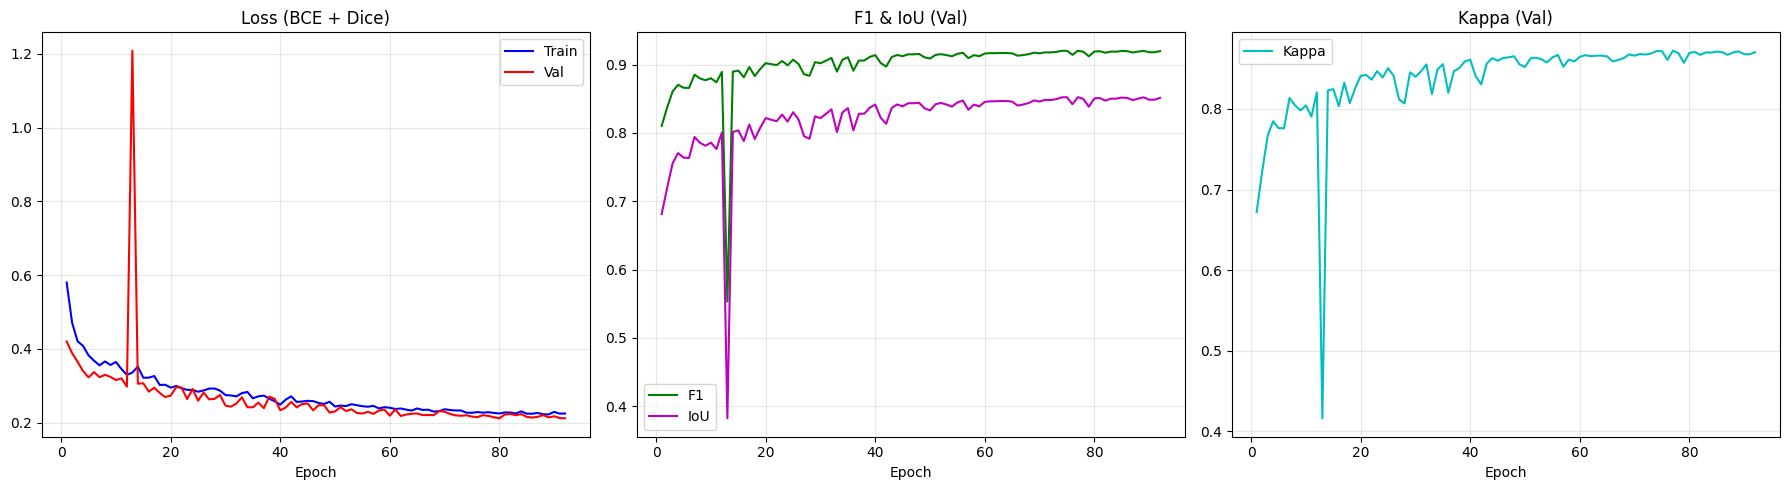

In [11]:
# ============================================================
# CELL 7: PLOT TRAINING CURVES
# ============================================================
import matplotlib.pyplot as plt

ep = [h['epoch'] for h in history]
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].plot(ep, [h['train_loss'] for h in history], 'b-', label='Train')
ax[0].plot(ep, [h['val_loss'] for h in history], 'r-', label='Val')
ax[0].set_title('Loss (BCE + Dice)'); ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(ep, [h['val_f1'] for h in history], 'g-', label='F1')
ax[1].plot(ep, [h['val_iou'] for h in history], 'm-', label='IoU')
ax[1].set_title('F1 & IoU (Val)'); ax[1].legend(); ax[1].grid(alpha=0.3)

ax[2].plot(ep, [h['val_kappa'] for h in history], 'c-', label='Kappa')
ax[2].set_title('Kappa (Val)'); ax[2].legend(); ax[2].grid(alpha=0.3)

for a in ax: a.set_xlabel('Epoch')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150)
plt.show()

In [12]:
# ============================================================
# CELL 8: INFERENCE → CHANGE MAP
# ============================================================

ckpt = torch.load(os.path.join(OUTPUT_DIR, 'best_biunet.pth'), map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f'Loaded best model (epoch {ckpt["epoch"]}, F1={ckpt["best_f1"]:.4f})')

print('Generating change map...')
_, H, W = img_t1.shape
inf_stride = STRIDE // 2

prob_map  = np.zeros((H, W), dtype=np.float64)
count_map = np.zeros((H, W), dtype=np.float64)

n_r = len(range(0, H-PATCH_SIZE+1, inf_stride))
n_c = len(range(0, W-PATCH_SIZE+1, inf_stride))
total = n_r * n_c; done = 0

with torch.no_grad():
    for r in range(0, H-PATCH_SIZE+1, inf_stride):
        for c in range(0, W-PATCH_SIZE+1, inf_stride):
            p1 = img_t1[:, r:r+PATCH_SIZE, c:c+PATCH_SIZE]
            p2 = img_t2[:, r:r+PATCH_SIZE, c:c+PATCH_SIZE]
            x = torch.from_numpy(np.concatenate([p1,p2],0)).float().unsqueeze(0).to(device)
            logits = model(x)
            if logits.shape[1] == 2: logits = logits[:, 1:2]
            probs = torch.sigmoid(logits).cpu().numpy()[0, 0]
            prob_map[r:r+PATCH_SIZE, c:c+PATCH_SIZE] += probs
            count_map[r:r+PATCH_SIZE, c:c+PATCH_SIZE] += 1.0
            done += 1
            if done % 200 == 0:
                print(f'  {done}/{total} ({done/total*100:.0f}%)', end='\r')

prob_map /= np.maximum(count_map, 1.0)
binary_map = (prob_map > 0.5).astype(np.uint8)

save_geotiff(os.path.join(OUTPUT_DIR, 'change_probability.tif'), prob_map, meta_mask)
save_geotiff(os.path.join(OUTPUT_DIR, 'change_prediction.tif'), binary_map.astype(np.float32), meta_mask)

print(f'\n✅ Change map saved!')
print(f'   Changed: {binary_map.sum()*9/10000:.1f} ha ({binary_map.mean()*100:.1f}%)')

Loaded best model (epoch 77, F1=0.9204)
Generating change map...

✅ Change map saved!
   Changed: 3370.4 ha (31.2%)


╔═══════════════════════════════════════════════════╗
║       FINAL RESULTS — BiUNet Change Detection     ║
╠═══════════════════════════════════════════════════╣
║  Precision        : 0.8129                         ║
║  Recall           : 0.9296                         ║
║  F1-Score         : 0.8673                         ║
║  IoU              : 0.7657                         ║
║  Overall Accuracy : 0.9225                         ║
║  Kappa Coefficient: 0.8129                         ║
╠═══════════════════════════════════════════════════╣
║  Changed area     :    3,370.4 ha               ║
║  Total area       :   10,809.6 ha               ║
║  Change %         :       31.2%                ║
╚═══════════════════════════════════════════════════╝


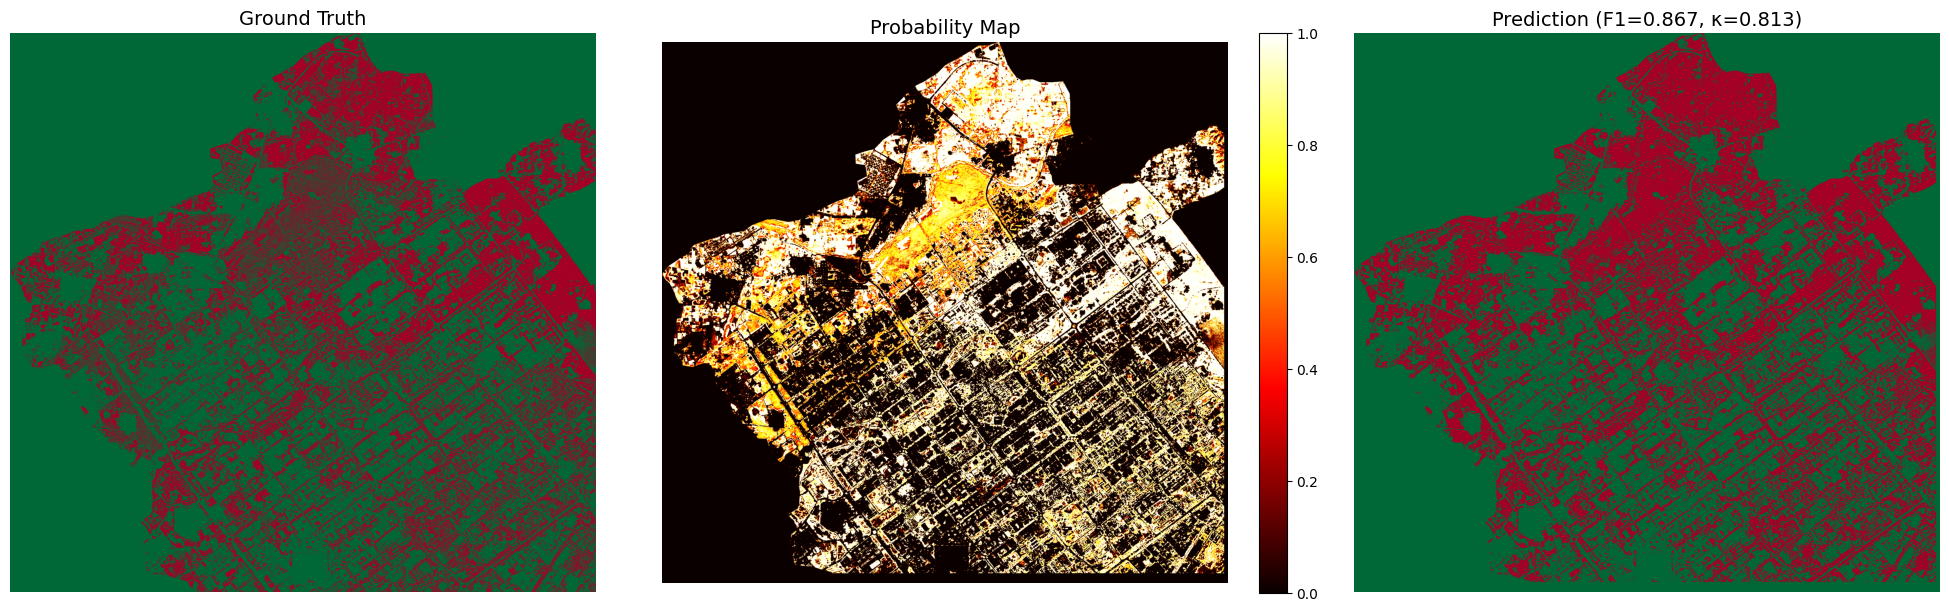


✅ All outputs saved to /content/outputs/


In [13]:
# ============================================================
# CELL 9: FINAL METRICS + VISUALIZATION
# ============================================================

gt   = mask.flatten().astype(int)
pred = binary_map.flatten().astype(int)
v = (gt >= 0) & (gt <= 1)

tp = np.sum((pred[v]==1)&(gt[v]==1))
fp = np.sum((pred[v]==1)&(gt[v]==0))
fn = np.sum((pred[v]==0)&(gt[v]==1))
tn = np.sum((pred[v]==0)&(gt[v]==0))

prec = tp/(tp+fp) if tp+fp else 0
rec  = tp/(tp+fn) if tp+fn else 0
f1   = 2*prec*rec/(prec+rec) if prec+rec else 0
iou  = tp/(tp+fp+fn) if tp+fp+fn else 0
oa   = (tp+tn)/v.sum()
kap  = cohen_kappa_score(gt[v], pred[v])

print('╔═══════════════════════════════════════════════════╗')
print('║       FINAL RESULTS — BiUNet Change Detection     ║')
print('╠═══════════════════════════════════════════════════╣')
print(f'║  Precision        : {prec:.4f}                         ║')
print(f'║  Recall           : {rec:.4f}                         ║')
print(f'║  F1-Score         : {f1:.4f}                         ║')
print(f'║  IoU              : {iou:.4f}                         ║')
print(f'║  Overall Accuracy : {oa:.4f}                         ║')
print(f'║  Kappa Coefficient: {kap:.4f}                         ║')
print(f'╠═══════════════════════════════════════════════════╣')
print(f'║  Changed area     : {binary_map.sum()*9/10000:>10,.1f} ha               ║')
print(f'║  Total area       : {binary_map.size*9/10000:>10,.1f} ha               ║')
print(f'║  Change %         : {binary_map.mean()*100:>10.1f}%                ║')
print('╚═══════════════════════════════════════════════════╝')

# Save report
report = {'model':'BiUNet', 'temporal':'2016→2025', 'resolution_m':3,
          'metrics':{'precision':round(prec,4),'recall':round(rec,4),
                     'f1':round(f1,4),'iou':round(iou,4),
                     'oa':round(oa,4),'kappa':round(kap,4)},
          'area':{'changed_ha':round(binary_map.sum()*9/10000,1),
                  'total_ha':round(binary_map.size*9/10000,1)}}
with open(os.path.join(OUTPUT_DIR, 'evaluation_report.json'), 'w') as f:
    json.dump(report, f, indent=2)

# Visualization
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

ax[0].imshow(mask, cmap='RdYlGn_r')
ax[0].set_title('Ground Truth', fontsize=14); ax[0].axis('off')

im = ax[1].imshow(prob_map, cmap='hot', vmin=0, vmax=1)
ax[1].set_title('Probability Map', fontsize=14); ax[1].axis('off')
plt.colorbar(im, ax=ax[1], fraction=0.046)

ax[2].imshow(binary_map, cmap='RdYlGn_r')
ax[2].set_title(f'Prediction (F1={f1:.3f}, κ={kap:.3f})', fontsize=14); ax[2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'results_comparison.png'), dpi=150)
plt.show()

print(f'\n✅ All outputs saved to {OUTPUT_DIR}/')

In [14]:
# ============================================================
# CELL 10: DOWNLOAD RESULTS
# ============================================================
from google.colab import files
import shutil

print('📁 Output files:\n')
for f in sorted(os.listdir(OUTPUT_DIR)):
    fp = os.path.join(OUTPUT_DIR, f)
    print(f'  📄 {f:40s} ({os.path.getsize(fp)/1e6:.1f} MB)')

# Zip everything for easy download
zip_path = '/content/biunet_results'
shutil.make_archive(zip_path, 'zip', OUTPUT_DIR)
print(f'\n📦 Zipped all outputs → biunet_results.zip')

# Auto-download
files.download(f'{zip_path}.zip')
print('\n✅ Download triggered! Check your browser downloads.')
print('   Open the .tif files in QGIS — CRS (UTM 43N) is preserved.')

📁 Output files:

  📄 best_biunet.pth                          (124.2 MB)
  📄 change_prediction.tif                    (1.8 MB)
  📄 change_probability.tif                   (48.9 MB)
  📄 evaluation_report.json                   (0.0 MB)
  📄 results_comparison.png                   (3.6 MB)
  📄 training_curves.png                      (0.1 MB)
  📄 training_history.json                    (0.0 MB)

📦 Zipped all outputs → biunet_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download triggered! Check your browser downloads.
   Open the .tif files in QGIS — CRS (UTM 43N) is preserved.
